# 1D Heat Equation via Finite Volume Method

This notebook imports the solver from `heat_equation_fvm.py` and computes the time evolution of the 1D heat equation, $u_t = \kappa u_{xx}$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import heat_equation_fvm

CFL number = 5.00000e-01
Computed solution on 100 cells and 1000 time steps.
Time step dt = 1.00000e-04


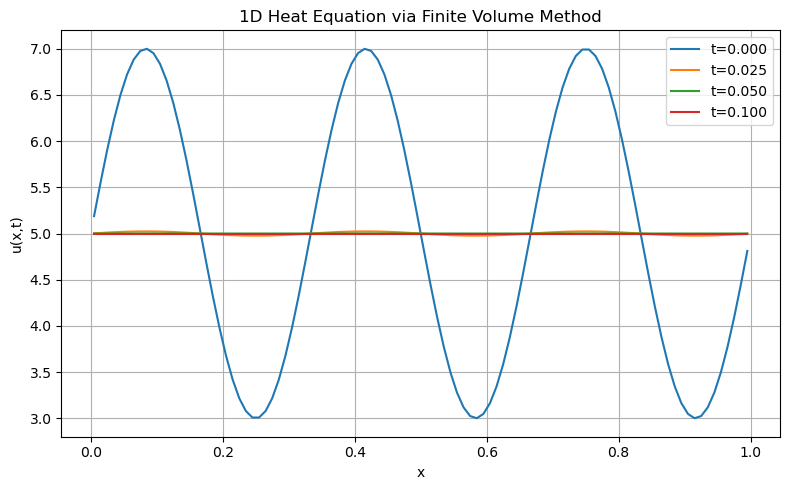

In [32]:
# Parameters for the finite volume solver
nx = 100
nt = 1000
t_end = 0.1
kappa = 0.5
length = 1.0
left_bc = 1.0
right_bc = 2.0

dx = length / nx
dt = t_end / nt
cfl = kappa * dt / dx**2
print(f'CFL number = {cfl:.5e}')

# Reload the module to get the latest changes
importlib.reload(heat_equation_fvm)

initial_condition = heat_equation_fvm.sinusoidal_initial_condition
# initial_condition = heat_equation_fvm.flat_initial_condition
x, times, solutions = heat_equation_fvm.solve_heat_equation_fvm(
    nx=nx,
    nt=nt,
    t_end=t_end,
    length=length,
    kappa=kappa,
    left_bc=left_bc,
    right_bc=right_bc,
    initial_condition=initial_condition,
    flux=heat_equation_fvm.heat_flux,
    periodic=True,
)

# print(solutions)
print(f'Computed solution on {nx} cells and {nt} time steps.')
print(f'Time step dt = {t_end/nt:.5e}')
# print(solutions[0]-solutions[-1])

selected_indices = [0, len(times)//4, len(times)//2, -1]
plt.figure(figsize=(8, 5))
for idx in selected_indices:
    plt.plot(x, solutions[idx], label=f't={times[idx]:.3f}')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('1D Heat Equation via Finite Volume Method')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Detected mode: 3
A0     = 2
decay  = 177.285
phase  = 1.65105e-16
offset = 5
RMS error = 5.98391e-15


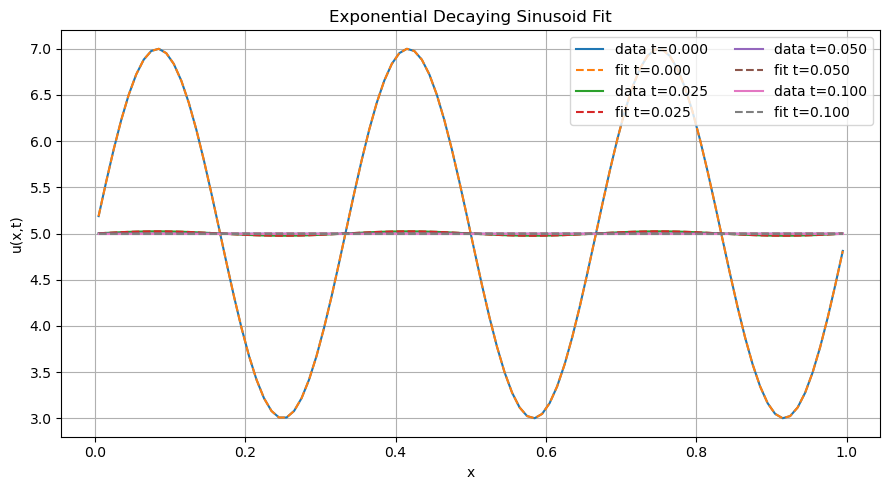

In [31]:
from scipy.optimize import curve_fit

# Fit model: u(x,t) = offset + A0 * exp(-decay * t) * sin(2*pi*mode*x/length + phase)
# Estimate dominant spatial mode from the initial condition.
initial_profile = solutions[0] - np.mean(solutions[0])
fft_mag = np.abs(np.fft.rfft(initial_profile))
if len(fft_mag) < 2 or np.allclose(fft_mag[1:], 0):
    raise RuntimeError("Could not detect a sinusoidal mode from the data.")
mode_guess = int(np.argmax(fft_mag[1:]) + 1)

X, T = np.meshgrid(x, times)
x_flat = X.ravel()
t_flat = T.ravel()
y_flat = solutions.ravel()


def exp_decay_sine_xt(x_t, A0, decay, phase, offset):
    x_vals, t_vals = x_t
    return offset + A0 * np.exp(-decay * t_vals) * np.sin(2 * np.pi * mode_guess * x_vals / length + phase)

A0_guess = 0.5 * (np.max(solutions[0]) - np.min(solutions[0]))
decay_guess = max(kappa * (2 * np.pi * mode_guess / length) ** 2, 1e-8)
phase_guess = 0.0
offset_guess = float(np.mean(solutions))

p0 = [A0_guess, decay_guess, phase_guess, offset_guess]
bounds = ([-np.inf, 0.0, -2 * np.pi, -np.inf], [np.inf, np.inf, 2 * np.pi, np.inf])

params, _ = curve_fit(
    exp_decay_sine_xt,
    (x_flat, t_flat),
    y_flat,
    p0=p0,
    bounds=bounds,
    maxfev=20000,
)

A0_fit, decay_fit, phase_fit, offset_fit = params
fitted = exp_decay_sine_xt((X, T), A0_fit, decay_fit, phase_fit, offset_fit)
rms_error = np.sqrt(np.mean((fitted - solutions) ** 2))

print(f"Detected mode: {mode_guess}")
print(f"A0     = {A0_fit:.6g}")
print(f"decay  = {decay_fit:.6g}")
print(f"phase  = {phase_fit:.6g}")
print(f"offset = {offset_fit:.6g}")
print(f"RMS error = {rms_error:.6g}")

# Visual comparison at selected times
selected = [0, len(times)//4, len(times)//2, -1]
plt.figure(figsize=(9, 5))
for idx in selected:
    plt.plot(x, solutions[idx], '-', label=f"data t={times[idx]:.3f}")
    plt.plot(x, fitted[idx], '--', label=f"fit t={times[idx]:.3f}")
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.title('Exponential Decaying Sinusoid Fit')
plt.legend(ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
from pathlib import Path
import multiprocessing as mp
import shutil
import subprocess


def _save_frame(args):
    frame_index, sol, t_value, x_vals, x_lim, y_lim, out_dir = args
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x_vals, sol, color="blue")
    ax.set_xlim(*x_lim)
    ax.set_ylim(*y_lim)
    ax.set_xlabel("x")
    ax.set_ylabel("u(x, t)")
    ax.set_title(f"1D Heat Equation Solution at t={t_value:.4f}")
    ax.grid(True)
    fig.savefig(Path(out_dir) / f"frame_{frame_index:04d}.png", dpi=120)
    plt.close(fig)


frames_dir = Path("frames")
frames_dir.mkdir(exist_ok=True)

x_lim = (0.0, float(length))
y_lim = (float(np.min(solutions)), float(np.max(solutions)))
y_lim = (0,10)

jobs = [
    (idx, solutions[idx], float(times[idx]), x, x_lim, y_lim, str(frames_dir))
    for idx in range(len(times))
]

num_workers = mp.cpu_count()
ctx = mp.get_context("fork")
with ctx.Pool(processes=num_workers) as pool:
    pool.map(_save_frame, jobs)

print(f"Saved {len(jobs)} frames to {frames_dir.resolve()} using {num_workers} cores")


frames_dir = Path("frames")
output_movie = Path("heat_solution.mp4")

if not frames_dir.exists():
    raise FileNotFoundError(f"Frames directory not found: {frames_dir.resolve()}")

if shutil.which("ffmpeg") is None:
    raise RuntimeError("ffmpeg is not installed or not found on PATH.")

subprocess.run(
    [
        "ffmpeg",
        "-y",
        "-framerate", "20",
        "-i", str(frames_dir / "frame_%04d.png"),
        "-c:v", "libx264",
        "-pix_fmt", "yuv420p",
        str(output_movie),
    ],
    check=True,
)

print(f"Saved movie to {output_movie.resolve()}")

Saved 1001 frames to /Users/tylertrent/Documents/GitHub/HeatDispersion_FiniteVolume/frames using 14 cores


ffmpeg version 4.2.2 Copyright (c) 2000-2019 the FFmpeg developers
  built with clang version 12.0.0
  configuration: --prefix=/Users/ktietz/demo/mc3/conda-bld/ffmpeg_1628925491858/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=arm64-apple-darwin20.0.0-clang --disable-doc --enable-avresample --enable-gmp --enable-hardcoded-tables --enable-libfreetype --enable-libvpx --enable-pthreads --enable-libopus --enable-postproc --enable-pic --enable-pthreads --enable-shared --enable-static --enable-version3 --enable-zlib --enable-libmp3lame --disable-nonfree --enable-gpl --enable-gnutls --disable-openssl --enable-libopenh264 --enable-libx264
  libavutil      56. 31.100 / 56. 31.100
  libavcodec     58. 54.100 / 58. 54.100
  libavformat    58. 29.100 / 58. 29.100
  libavdevice    58.  8.100 / 58.  8.100
  libavfilter     7. 57.100 /  7. 57

Saved movie to /Users/tylertrent/Documents/GitHub/HeatDispersion_FiniteVolume/heat_solution.mp4


frame= 1001 fps=633 q=-1.0 Lsize=     338kB time=00:00:49.90 bitrate=  55.4kbits/s speed=31.5x    
video:325kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 3.860646%
[libx264 @ 0x14b02d600] frame I:5     Avg QP:14.31  size: 17470
[libx264 @ 0x14b02d600] frame P:269   Avg QP:21.13  size:   590
[libx264 @ 0x14b02d600] frame B:727   Avg QP:30.77  size:   118
[libx264 @ 0x14b02d600] consecutive B-frames:  0.6%  7.4%  0.9% 91.1%
[libx264 @ 0x14b02d600] mb I  I16..4: 61.2% 22.7% 16.1%
[libx264 @ 0x14b02d600] mb P  I16..4:  0.1%  0.0%  0.0%  P16..4:  1.6%  0.3%  0.3%  0.0%  0.0%    skip:97.7%
[libx264 @ 0x14b02d600] mb B  I16..4:  0.0%  0.1%  0.0%  B16..8:  0.8%  0.1%  0.0%  direct: 0.0%  skip:98.9%  L0:47.8% L1:50.3% BI: 1.9%
[libx264 @ 0x14b02d600] 8x8 transform intra:26.9% inter:19.0%
[libx264 @ 0x14b02d600] coded y,uvDC,uvAC intra: 10.7% 9.8% 9.0% inter: 0.2% 0.2% 0.2%
[libx264 @ 0x14b02d600] i16 v,h,dc,p: 74% 20%  6%  0%
[libx264 @ 0x14b02d600] i8 v,h,dc,d

In [ ]:
# Compute fractional differences from initial state
initial_state = solutions[0]
fractional_diffs = np.array([(sol - initial_state) / np.where(initial_state != 0, initial_state, 1) for sol in solutions])

# Compute average, min, and max fractional difference for each time step
median_fractional_diff = np.median(np.abs(fractional_diffs), axis=1)
min_fractional_diff = np.min(np.abs(fractional_diffs), axis=1)
max_fractional_diff = np.max(np.abs(fractional_diffs), axis=1)

# Plot median, min, and max fractional differences vs time
plt.figure(figsize=(8, 5))
plt.plot(times, median_fractional_diff, label='Median |fractional difference|')
plt.plot(times, min_fractional_diff, label='Min |fractional difference|')
plt.plot(times, max_fractional_diff, label='Max |fractional difference|')
plt.xlabel('Time')
plt.ylabel('Fractional Difference')
plt.title('Fractional Difference from Initial State vs Time')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [ ]:
# Plot spatial distribution of fractional differences at selected times
selected_time_indices = [0, len(times)//4, len(times)//2, -1]
plt.figure(figsize=(8, 5))
for idx in selected_time_indices:
    plt.plot(x, fractional_diffs[idx], label=f't={times[idx]:.3f}')
plt.xlabel('x')
plt.ylabel('Fractional Difference')
plt.title('Spatial Distribution of Fractional Differences')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()